# 1. Objective

Run the next image-embedding experiments without changing the stable baseline notebook. This notebook compares submission-safe image features, TorchVision EfficientNet-B0 image embeddings, and reduced embedding variants under grouped cross-validation.

The default setup is for research runs after the competition deadline: internet downloads are allowed so TorchVision can fetch EfficientNet-B0 ImageNet weights. No Kaggle model input is required for this version. If you later need a fully offline run, switch `ALLOW_MODEL_DOWNLOAD` to `False` and provide a compatible PyTorch `.pth` weight file.


In [7]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageStat
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)

sns.set_theme(style='whitegrid', palette='viridis', rc={
    'figure.figsize': (11, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

DATA_DIR = Path('/kaggle/input/competitions/csiro-biomass')
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_ORDER = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
TARGET_WEIGHTS = {
    'Dry_Green_g': 0.1,
    'Dry_Dead_g': 0.1,
    'Dry_Clover_g': 0.1,
    'GDM_g': 0.2,
    'Dry_Total_g': 0.5,
}

# Research default: internet can be on because the competition deadline has passed.
# TorchVision will download EfficientNet-B0 ImageNet weights when no local .pth file is supplied.
ALLOW_MODEL_DOWNLOAD = True
EMBEDDING_BACKBONE = 'efficientnet_b0_torchvision'

# Optional compatible local PyTorch state dict for offline reproducibility. Example:
# LOCAL_EFFNET_B0_WEIGHTS = '/kaggle/input/efficientnet-b0-pytorch/efficientnet_b0_rwightman-7f5810bc.pth'
LOCAL_EFFNET_B0_WEIGHTS = None

if not DATA_DIR.exists():
    raise FileNotFoundError(f'Expected Kaggle input at {DATA_DIR}')

print(f'Data directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'Embedding backbone: {EMBEDDING_BACKBONE}')
print(f'ALLOW_MODEL_DOWNLOAD: {ALLOW_MODEL_DOWNLOAD}')
print('Kaggle model input is not required for the TorchVision download path.')


Data directory: /kaggle/input/competitions/csiro-biomass
Output directory: /kaggle/working
Embedding backbone: efficientnet_b0_torchvision
ALLOW_MODEL_DOWNLOAD: True
Kaggle model input is not required for the TorchVision download path.


# 2. Data and Validation

## 2.1 Load Competition Files

In [8]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f'train: {train.shape} | train images: {train.image_path.nunique():,}')
print(f'test: {test.shape} | test images: {test.image_path.nunique():,}')
print(f'sample_submission: {sample_submission.shape}')
display(train.head())
display(test.head())

train: (1785, 9) | train images: 357
test: (5, 3) | test images: 1
sample_submission: (5, 2)


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


,sample_id,image_path,target_name
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g


## 2.2 Metric and Grouped Folds

In [9]:
def weighted_r2_score(y_true, y_pred, weights):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weighted_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * np.square(y_true - y_pred))
    ss_tot = np.sum(weights * np.square(y_true - weighted_mean))
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

train = train.copy()
train['target_weight'] = train['target_name'].map(TARGET_WEIGHTS)

gkf = GroupKFold(n_splits=5)
train['fold'] = -1
for fold, (_, val_idx) in enumerate(gkf.split(train, groups=train['image_path']), start=1):
    train.loc[val_idx, 'fold'] = fold

display(pd.crosstab(train['fold'], train['target_name']))

target_name,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
fold,,,,,
1,72,72,72,72,72
2,72,72,72,72,72
3,71,71,71,71,71
4,71,71,71,71,71
5,71,71,71,71,71


# 3. Feature Frames

## 3.1 Image-Level Table

In [10]:
meta_cols = ['image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'fold']
image_meta = train[meta_cols].drop_duplicates('image_path').copy()
image_targets = train.pivot_table(index='image_path', columns='target_name', values='target', aggfunc='first').reset_index()
image_train = image_meta.merge(image_targets, on='image_path', how='left')

test_image = test.drop_duplicates('image_path').copy()
for col in ['Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']:
    if col not in test_image.columns:
        test_image[col] = np.nan

print(image_train.shape, test_image.shape)
display(image_train.head())

(357, 12) (1, 8)


,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,fold,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,1,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,5,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000,4,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,2015/5/18,Tas,Ryegrass,0.66,5.0000,3,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,2015/9/11,Tas,Ryegrass,0.54,3.5000,2,0.4343,23.2239,10.5261,34.1844,10.9605


## 3.2 Metadata Features

In [11]:
def add_metadata_features(df):
    out = df.copy()
    dates = pd.to_datetime(out.get('Sampling_Date'), errors='coerce')
    out['sample_month'] = dates.dt.month
    out['sample_dayofyear'] = dates.dt.dayofyear
    out['sample_year'] = dates.dt.year
    species = out['Species'].fillna('Unknown').astype(str)
    out['primary_species'] = species.str.split('_').str[0]
    out['species_count'] = np.where(species.eq('Unknown'), 0, species.str.count('_') + 1)
    out['ndvi_x_height'] = out['Pre_GSHH_NDVI'] * out['Height_Ave_cm']
    out['height_log1p'] = np.log1p(out['Height_Ave_cm'].clip(lower=0))
    return out

image_train = add_metadata_features(image_train)
test_image = add_metadata_features(test_image)

## 3.3 Color Features

In [12]:
def extract_image_features(df, cache_name):
    cache_path = OUTPUT_DIR / cache_name
    if cache_path.exists():
        print(f'Loading cached features: {cache_path}')
        return pd.read_csv(cache_path)

    rows = []
    for rel_path in tqdm(df['image_path'].drop_duplicates().tolist(), desc=cache_name):
        path = DATA_DIR / rel_path
        row = {'image_path': rel_path}
        try:
            img = Image.open(path).convert('RGB')
            row['width'], row['height'] = img.size
            small = img.resize((256, 256))
            arr = np.asarray(small, dtype=np.float32) / 255.0
            stat = ImageStat.Stat(small)
            for idx, ch in enumerate(['r', 'g', 'b']):
                row[f'{ch}_mean'] = stat.mean[idx] / 255.0
                row[f'{ch}_std'] = stat.stddev[idx] / 255.0
                row[f'{ch}_p10'] = np.quantile(arr[:, :, idx], 0.10)
                row[f'{ch}_p50'] = np.quantile(arr[:, :, idx], 0.50)
                row[f'{ch}_p90'] = np.quantile(arr[:, :, idx], 0.90)
            red, green, blue = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
            row['brightness'] = arr.mean()
            row['contrast'] = arr.std()
            row['excess_green'] = np.mean(2 * green - red - blue)
            row['green_red_ratio'] = np.mean(green / (red + 1e-4))
            row['visible_ndvi_proxy'] = np.mean((green - red) / (green + red + 1e-4))
        except Exception as exc:
            row['image_error'] = str(exc)
        rows.append(row)

    features = pd.DataFrame(rows)
    features.to_csv(cache_path, index=False)
    print(f'Wrote {cache_path}')
    return features

train_img = extract_image_features(image_train, 'train_image_features.csv')
test_img = extract_image_features(test_image, 'test_image_features.csv')

image_train = image_train.merge(train_img, on='image_path', how='left')
test_image = test_image.merge(test_img, on='image_path', how='left')
print(f'Color feature columns: {len([c for c in train_img.columns if c != "image_path"])}')

train_image_features.csv:   0%|          | 0/357 [00:00<?, ?it/s]

Wrote /kaggle/working/train_image_features.csv


test_image_features.csv:   0%|          | 0/1 [00:00<?, ?it/s]

Wrote /kaggle/working/test_image_features.csv
Color feature columns: 22


# 4. TorchVision EfficientNet-B0 Embeddings

The extractor uses **TorchVision EfficientNet-B0 with ImageNet weights**. For the current research run, leave internet enabled and keep `ALLOW_MODEL_DOWNLOAD = True`; TorchVision will download the correct PyTorch weights automatically.

Recommended options:

1. Fast research run: use TorchVision download, with no additional Kaggle model input.
2. Offline reproducible run: attach a compatible PyTorch `.pth` EfficientNet-B0 state dict and set `LOCAL_EFFNET_B0_WEIGHTS`.
3. Treat TensorFlow, EfficientNetV2, or larger EfficientNet variants as separate experiments after this B0 benchmark is clear.


In [13]:
def find_cached_effnet_weights():
    candidates = []
    if LOCAL_EFFNET_B0_WEIGHTS:
        candidates.append(Path(LOCAL_EFFNET_B0_WEIGHTS))
    candidates.extend(Path('/root/.cache/torch/hub/checkpoints').glob('efficientnet_b0*.pth'))
    candidates.extend(Path('/kaggle/input').glob('**/efficientnet_b0*.pth'))
    candidates = [p for p in candidates if p.exists()]
    return candidates[0] if candidates else None

def empty_embedding_frame(df):
    return pd.DataFrame({'image_path': df['image_path'].drop_duplicates().tolist()})

def load_embedding_cache(cache_path):
    if not cache_path.exists():
        return None
    cached = pd.read_csv(cache_path)
    eff_cols = [c for c in cached.columns if c.startswith('effnet_b0_')]
    if eff_cols:
        print(f'Loading cached embeddings: {cache_path} ({len(eff_cols)} features)')
        return cached
    if ALLOW_MODEL_DOWNLOAD:
        print(f'Ignoring empty embedding cache because downloads are enabled: {cache_path}')
        return None
    print(f'Loading empty embedding cache: {cache_path}')
    return cached

def extract_effnet_b0_embeddings(df, cache_name, batch_size=16):
    cache_path = OUTPUT_DIR / cache_name
    cached = load_embedding_cache(cache_path)
    if cached is not None:
        return cached

    try:
        import torch
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
    except Exception as exc:
        print(f'Skipping embeddings; torch/torchvision unavailable: {exc}')
        return empty_embedding_frame(df)

    weight_path = find_cached_effnet_weights()
    if weight_path is None and not ALLOW_MODEL_DOWNLOAD:
        print('Skipping embeddings; no local PyTorch EfficientNet-B0 weights found and downloads are disabled.')
        return empty_embedding_frame(df)

    try:
        if weight_path is not None:
            print(f'Using local PyTorch EfficientNet-B0 weights: {weight_path}')
            model = efficientnet_b0(weights=None)
            state = torch.load(weight_path, map_location='cpu')
            model.load_state_dict(state)
            preprocess = EfficientNet_B0_Weights.DEFAULT.transforms()
        else:
            print('Downloading TorchVision EfficientNet-B0 ImageNet weights because ALLOW_MODEL_DOWNLOAD=True.')
            weights = EfficientNet_B0_Weights.DEFAULT
            model = efficientnet_b0(weights=weights)
            preprocess = weights.transforms()
    except Exception as exc:
        print(f'Skipping embeddings; EfficientNet-B0 weights could not be loaded: {exc}')
        return empty_embedding_frame(df)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.classifier = torch.nn.Identity()
    model = model.to(device).eval()

    rows = []
    unique_paths = df['image_path'].drop_duplicates().tolist()
    with torch.no_grad():
        for start in tqdm(range(0, len(unique_paths), batch_size), desc=cache_name):
            batch_paths = unique_paths[start:start + batch_size]
            images = []
            kept_paths = []
            for rel_path in batch_paths:
                try:
                    img = Image.open(DATA_DIR / rel_path).convert('RGB')
                    images.append(preprocess(img))
                    kept_paths.append(rel_path)
                except Exception as exc:
                    print(f'Skipping {rel_path}: {exc}')
            if not images:
                continue
            feats = model(torch.stack(images).to(device)).detach().cpu().numpy()
            for rel_path, vec in zip(kept_paths, feats):
                row = {'image_path': rel_path}
                row.update({f'effnet_b0_{i:04d}': float(v) for i, v in enumerate(vec)})
                rows.append(row)

    embeddings = pd.DataFrame(rows) if rows else empty_embedding_frame(df)
    embeddings.to_csv(cache_path, index=False)
    print(f'Wrote {cache_path}')
    return embeddings

train_emb = extract_effnet_b0_embeddings(image_train, 'train_effnet_b0_embeddings.csv')
test_emb = extract_effnet_b0_embeddings(test_image, 'test_effnet_b0_embeddings.csv')

image_train = image_train.merge(train_emb, on='image_path', how='left')
test_image = test_image.merge(test_emb, on='image_path', how='left')
embedding_cols = [c for c in image_train.columns if c.startswith('effnet_b0_')]
print(f'Embedding features available: {len(embedding_cols)}')


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 236MB/s]


train_effnet_b0_embeddings.csv:   0%|          | 0/23 [00:00<?, ?it/s]

Wrote /kaggle/working/train_effnet_b0_embeddings.csv
Using local PyTorch EfficientNet-B0 weights: /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


test_effnet_b0_embeddings.csv:   0%|          | 0/1 [00:00<?, ?it/s]

Wrote /kaggle/working/test_effnet_b0_embeddings.csv
Embedding features available: 1280


# 5. Experiment Matrix

## 5.1 Long-Format Dataset

In [14]:
def to_long(df, include_targets=True):
    repeated = []
    for target_name in TARGET_ORDER:
        tmp = df.copy()
        tmp['target_name'] = target_name
        tmp['target_weight'] = TARGET_WEIGHTS[target_name]
        if include_targets:
            tmp['target'] = tmp[target_name]
        repeated.append(tmp)
    return pd.concat(repeated, ignore_index=True)

train_long = to_long(image_train, include_targets=True)
test_long = test.merge(test_image.drop(columns=[c for c in ['sample_id', 'target_name'] if c in test_image.columns]), on='image_path', how='left')
test_long['target_weight'] = test_long['target_name'].map(TARGET_WEIGHTS)

image_feature_base = [
    'width', 'height', 'brightness', 'contrast', 'excess_green', 'green_red_ratio', 'visible_ndvi_proxy',
    'r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std',
    'r_p10', 'r_p50', 'r_p90', 'g_p10', 'g_p50', 'g_p90', 'b_p10', 'b_p50', 'b_p90',
]
metadata_feature_base = [
    'State', 'Species', 'primary_species', 'species_count', 'Pre_GSHH_NDVI', 'Height_Ave_cm',
    'ndvi_x_height', 'height_log1p', 'sample_month', 'sample_dayofyear', 'sample_year',
]

image_cols = ['target_name'] + [c for c in image_feature_base if c in train_long.columns]
metadata_cols = ['target_name'] + [c for c in metadata_feature_base if c in train_long.columns]
tabular_color_cols = list(dict.fromkeys(image_cols + metadata_cols))
embedding_cols = [c for c in train_long.columns if c.startswith('effnet_b0_')]

print(f'image/color features: {len(image_cols)}')
print(f'tabular/color features: {len(tabular_color_cols)}')
print(f'embedding features: {len(embedding_cols)}')

image/color features: 23
tabular/color features: 34
embedding features: 1280


## 5.2 PCA Embedding Features

Create multiple PCA projections so the notebook can test whether a lower-dimensional embedding representation is easier for classical models to use. These projections are diagnostic features; only promote them if grouped CV and segment diagnostics improve.


In [15]:
pca_feature_sets = {}
PCA_COMPONENT_OPTIONS = [16, 32, 64, 128]

if embedding_cols:
    max_components = min(len(embedding_cols), image_train.shape[0] - 1)
    for requested_components in PCA_COMPONENT_OPTIONS:
        n_components = min(requested_components, max_components)
        if n_components in pca_feature_sets:
            continue
        pca = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_components, random_state=2026)),
        ])
        image_pca = pca.fit_transform(image_train[embedding_cols])
        test_pca = pca.transform(test_image[embedding_cols])
        cols = [f'effnet_b0_pca_{n_components}_{i:03d}' for i in range(n_components)]
        image_train[cols] = image_pca
        test_image[cols] = test_pca
        pca_feature_sets[n_components] = cols
        print(f'Created {len(cols)} PCA embedding features for n_components={n_components}')

    train_long = to_long(image_train, include_targets=True)
    test_long = test.merge(test_image.drop(columns=[c for c in ['sample_id', 'target_name'] if c in test_image.columns]), on='image_path', how='left')
    test_long['target_weight'] = test_long['target_name'].map(TARGET_WEIGHTS)
else:
    print('No embeddings available; skipping PCA features.')


Created 16 PCA embedding features for n_components=16
Created 32 PCA embedding features for n_components=32
Created 64 PCA embedding features for n_components=64
Created 128 PCA embedding features for n_components=128


## 5.3 Models and Evaluation Helpers

Tree models are strong for tabular/color features, but dense CNN embeddings often work better with regularized linear models. This section evaluates ExtraTrees, raw-target Ridge, and log-target Ridge variants while keeping the grouped validation split identical across experiments.


In [16]:
def make_preprocess(cols, scale_numeric=False):
    cat_cols = [c for c in ['target_name', 'State', 'Species', 'primary_species'] if c in cols]
    num_cols = [c for c in cols if c not in cat_cols]
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(num_steps), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=3)),
        ]), cat_cols),
    ])

def fit_with_weights(model, X, y, sample_weight):
    try:
        return model.fit(X, y, model__sample_weight=sample_weight)
    except TypeError:
        return model.fit(X, y)

def parse_ridge_alpha(model_name, default=25.0):
    if '_a' not in model_name:
        return default
    try:
        return float(model_name.rsplit('_a', 1)[1].replace('p', '.'))
    except ValueError:
        return default

def uses_log_target(model_name):
    return model_name.startswith('ridge_log')

def make_model(model_name, cols, seed=2026):
    if model_name == 'extra_trees':
        reg = ExtraTreesRegressor(
            n_estimators=400,
            min_samples_leaf=3,
            max_features=0.75,
            random_state=seed,
            n_jobs=-1,
        )
        return Pipeline([('preprocess', make_preprocess(cols)), ('model', reg)])
    if model_name == 'ridge' or model_name.startswith('ridge_log'):
        reg = Ridge(alpha=parse_ridge_alpha(model_name), random_state=seed)
        return Pipeline([('preprocess', make_preprocess(cols, scale_numeric=True)), ('model', reg)])
    if model_name == 'hgb':
        reg = HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.04,
            l2_regularization=0.05,
            max_leaf_nodes=31,
            random_state=seed,
        )
        return Pipeline([('preprocess', make_preprocess(cols)), ('model', reg)])
    raise ValueError(model_name)

def run_grouped_cv(experiment_name, cols, model_name='extra_trees'):
    cols = [c for c in cols if c in train_long.columns]
    parts = []
    print(f'Running {experiment_name}: {model_name}, {len(cols)} features')
    for fold in sorted(train_long['fold'].unique()):
        trn = train_long[train_long['fold'] != fold]
        val = train_long[train_long['fold'] == fold]
        model = make_model(model_name, cols, seed=2026 + int(fold))
        y_train = np.log1p(trn['target']) if uses_log_target(model_name) else trn['target']
        model = fit_with_weights(model, trn[cols], y_train, trn['target_weight'])
        pred = model.predict(val[cols])
        if uses_log_target(model_name):
            pred = np.expm1(pred)
        pred = np.clip(pred, 0, None)
        keep_cols = [c for c in ['image_path', 'fold', 'State', 'primary_species', 'target_name', 'target', 'target_weight'] if c in val.columns]
        tmp = val[keep_cols].copy()
        tmp['prediction'] = pred
        tmp['experiment'] = experiment_name
        tmp['model'] = model_name
        tmp['experiment_label'] = f'{experiment_name}__{model_name}'
        parts.append(tmp)
    out = pd.concat(parts, ignore_index=True)
    out['error'] = out['prediction'] - out['target']
    out['abs_error'] = out['error'].abs()
    return out

def apply_total_constraint(long_df, pred_col='prediction'):
    wide = long_df.pivot_table(index='image_path', columns='target_name', values=pred_col, aggfunc='first')
    required = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g']
    if not all(c in wide.columns for c in required):
        return long_df.copy()
    constrained_total = wide[required].sum(axis=1)
    out = long_df.copy()
    mask = out['target_name'].eq('Dry_Total_g')
    out.loc[mask, pred_col] = out.loc[mask, 'image_path'].map(constrained_total)
    out['error'] = out[pred_col] - out['target']
    out['abs_error'] = out['error'].abs()
    return out

def summarize_oof(oof):
    rows = []
    for (experiment, model), group in oof.groupby(['experiment', 'model']):
        constrained = apply_total_constraint(group)
        raw_r2 = weighted_r2_score(group['target'], group['prediction'], group['target_weight'])
        constrained_r2 = weighted_r2_score(constrained['target'], constrained['prediction'], constrained['target_weight'])
        rows.append({
            'experiment': experiment,
            'model': model,
            'experiment_label': f'{experiment}__{model}',
            'raw_weighted_r2': raw_r2,
            'constrained_weighted_r2': constrained_r2,
            'constraint_delta': constrained_r2 - raw_r2,
            'use_constraint': constrained_r2 >= raw_r2,
            'mae': mean_absolute_error(group['target'], group['prediction']),
            'bias': np.mean(group['error']),
        })
    return pd.DataFrame(rows).sort_values('constrained_weighted_r2', ascending=False)


# 6. Run Experiments

The oracle metadata experiment remains diagnostic because hidden test metadata may be unavailable. The embedding comparison now includes raw-target Ridge and log-target Ridge alpha sweeps, because the target distributions are skewed and dense CNN features often need stronger regularization than tree models.


In [17]:
RIDGE_LOG_MODELS = ['ridge_log_a1', 'ridge_log_a10', 'ridge_log_a100']
EMBEDDING_LINEAR_MODELS = ['ridge'] + RIDGE_LOG_MODELS

experiment_configs = [
    {'experiment': 'image_color_only', 'cols': image_cols, 'models': ['extra_trees', 'ridge_log_a10']},
    {'experiment': 'tabular_color_oracle', 'cols': tabular_color_cols, 'models': ['extra_trees', 'ridge_log_a10']},
]

if embedding_cols:
    experiment_configs.extend([
        {'experiment': 'embeddings_only', 'cols': ['target_name'] + embedding_cols, 'models': ['extra_trees'] + EMBEDDING_LINEAR_MODELS},
        {'experiment': 'image_color_plus_embeddings', 'cols': list(dict.fromkeys(image_cols + embedding_cols)), 'models': ['extra_trees'] + EMBEDDING_LINEAR_MODELS},
    ])

for n_components, cols in pca_feature_sets.items():
    experiment_configs.extend([
        {'experiment': f'embedding_pca_{n_components}', 'cols': ['target_name'] + cols, 'models': ['extra_trees'] + EMBEDDING_LINEAR_MODELS},
        {'experiment': f'image_color_plus_embedding_pca_{n_components}', 'cols': list(dict.fromkeys(image_cols + cols)), 'models': ['extra_trees'] + EMBEDDING_LINEAR_MODELS},
    ])

oof_parts = []
for config in experiment_configs:
    for model_name in config['models']:
        oof_parts.append(run_grouped_cv(config['experiment'], config['cols'], model_name=model_name))

experiment_oof = pd.concat(oof_parts, ignore_index=True)
experiment_summary = summarize_oof(experiment_oof)
display(experiment_summary.round(5))

experiment_oof.to_csv(OUTPUT_DIR / 'embedding_experiment_oof.csv', index=False)
experiment_summary.to_csv(OUTPUT_DIR / 'embedding_experiment_summary.csv', index=False)
print(f'Wrote {OUTPUT_DIR / "embedding_experiment_oof.csv"}')
print(f'Wrote {OUTPUT_DIR / "embedding_experiment_summary.csv"}')


Running image_color_only: extra_trees, 23 features
Running image_color_only: ridge_log_a10, 23 features
Running tabular_color_oracle: extra_trees, 34 features
Running tabular_color_oracle: ridge_log_a10, 34 features
Running embeddings_only: extra_trees, 1281 features
Running embeddings_only: ridge, 1281 features
Running embeddings_only: ridge_log_a1, 1281 features
Running embeddings_only: ridge_log_a10, 1281 features
Running embeddings_only: ridge_log_a100, 1281 features
Running image_color_plus_embeddings: extra_trees, 1303 features
Running image_color_plus_embeddings: ridge, 1303 features
Running image_color_plus_embeddings: ridge_log_a1, 1303 features
Running image_color_plus_embeddings: ridge_log_a10, 1303 features
Running image_color_plus_embeddings: ridge_log_a100, 1303 features
Running embedding_pca_16: extra_trees, 17 features
Running embedding_pca_16: ridge, 17 features
Running embedding_pca_16: ridge_log_a1, 17 features
Running embedding_pca_16: ridge_log_a10, 17 features
Run

,experiment,model,experiment_label,raw_weighted_r2,constrained_weighted_r2,constraint_delta,use_constraint,mae,bias
52,tabular_color_oracle,extra_trees,tabular_color_oracle__extra_trees,0.80604,0.81102,0.00498,True,6.85461,0.21583
20,embeddings_only,extra_trees,embeddings_only__extra_trees,0.64197,0.64468,0.00271,True,9.85128,0.33001
47,image_color_plus_embeddings,extra_trees,image_color_plus_embeddings__extra_trees,0.64575,0.64175,-0.00400,False,9.70335,0.32066
37,image_color_plus_embedding_pca_32,extra_trees,image_color_plus_embedding_pca_32__extra_trees,0.61672,0.61578,-0.00094,False,9.96519,0.27007
32,image_color_plus_embedding_pca_16,extra_trees,image_color_plus_embedding_pca_16__extra_trees,0.61235,0.61130,-0.00104,False,9.89626,0.19731
5,embedding_pca_16,extra_trees,embedding_pca_16__extra_trees,0.60135,0.60647,0.00512,True,10.21546,0.21551
10,embedding_pca_32,extra_trees,embedding_pca_32__extra_trees,0.60667,0.60618,-0.00049,False,10.29658,0.38255
42,image_color_plus_embedding_pca_64,extra_trees,image_color_plus_embedding_pca_64__extra_trees,0.60784,0.60130,-0.00654,False,10.11494,0.40708
15,embedding_pca_64,extra_trees,embedding_pca_64__extra_trees,0.59373,0.58773,-0.00599,False,10.50325,0.57395
27,image_color_plus_embedding_pca_128,extra_trees,image_color_plus_embedding_pca_128__extra_trees,0.59081,0.58498,-0.00583,False,10.43747,0.46234


Wrote /kaggle/working/embedding_experiment_oof.csv
Wrote /kaggle/working/embedding_experiment_summary.csv


# 7. Segment Diagnostics

Focus on the best constrained score, then inspect target and state segments. A model is only worth promoting if it improves grouped CV and does not worsen the NSW high-biomass errors.


In [18]:
best_row = experiment_summary.iloc[0]
best_label = best_row['experiment_label']
best_oof_raw = experiment_oof[experiment_oof['experiment_label'].eq(best_label)].copy()
best_oof = apply_total_constraint(best_oof_raw) if best_row['use_constraint'] else best_oof_raw.copy()

per_target = (
    best_oof.groupby('target_name')
    .apply(lambda x: pd.Series({
        'weighted_r2': weighted_r2_score(x['target'], x['prediction'], x['target_weight']),
        'mae': mean_absolute_error(x['target'], x['prediction']),
        'bias': np.mean(x['error']),
        'target_mean': x['target'].mean(),
    }))
    .reset_index()
    .sort_values('weighted_r2', ascending=False)
)

segment_error = (
    best_oof.groupby(['target_name', 'State'])
    .agg(rows=('target', 'size'), mae=('abs_error', 'mean'), bias=('error', 'mean'), target_mean=('target', 'mean'))
    .reset_index()
    .sort_values('mae', ascending=False)
)

print(f'Best experiment: {best_label}')
print(f'Raw weighted R2:         {best_row["raw_weighted_r2"]:.5f}')
print(f'Constrained weighted R2: {best_row["constrained_weighted_r2"]:.5f}')
print(f'Use total constraint:    {best_row["use_constraint"]}')
display(per_target.round(4))
display(segment_error.head(20).round(3))

per_target.to_csv(OUTPUT_DIR / 'embedding_experiment_per_target.csv', index=False)
segment_error.to_csv(OUTPUT_DIR / 'embedding_experiment_segment_error.csv', index=False)
print(f'Wrote {OUTPUT_DIR / "embedding_experiment_per_target.csv"}')
print(f'Wrote {OUTPUT_DIR / "embedding_experiment_segment_error.csv"}')


Best experiment: tabular_color_oracle__extra_trees
Raw weighted R2:         0.80604
Constrained weighted R2: 0.81102
Use total constraint:    True


,target_name,weighted_r2,mae,bias,target_mean
4,GDM_g,0.7997,7.3681,0.2859,33.2744
2,Dry_Green_g,0.7806,7.1444,0.3438,26.6247
3,Dry_Total_g,0.7466,10.0548,0.5956,45.3181
0,Dry_Clover_g,0.6018,3.9574,0.1024,6.6497
1,Dry_Dead_g,0.4963,5.6671,0.1486,12.0445


,target_name,State,rows,mae,bias,target_mean
12,Dry_Total_g,NSW,75,16.668,0.735,70.897
16,GDM_g,NSW,75,14.014,0.189,56.694
8,Dry_Green_g,NSW,75,13.583,-0.008,56.559
3,Dry_Clover_g,WA,32,9.862,-1.901,22.088
13,Dry_Total_g,Tas,138,9.427,0.266,36.798
15,Dry_Total_g,WA,32,8.376,-0.017,31.388
4,Dry_Dead_g,NSW,75,8.032,0.402,14.203
19,GDM_g,WA,32,7.756,-0.463,31.388
14,Dry_Total_g,Vic,112,6.879,1.084,42.667
5,Dry_Dead_g,Tas,138,6.533,-0.322,15.231


Wrote /kaggle/working/embedding_experiment_per_target.csv
Wrote /kaggle/working/embedding_experiment_segment_error.csv


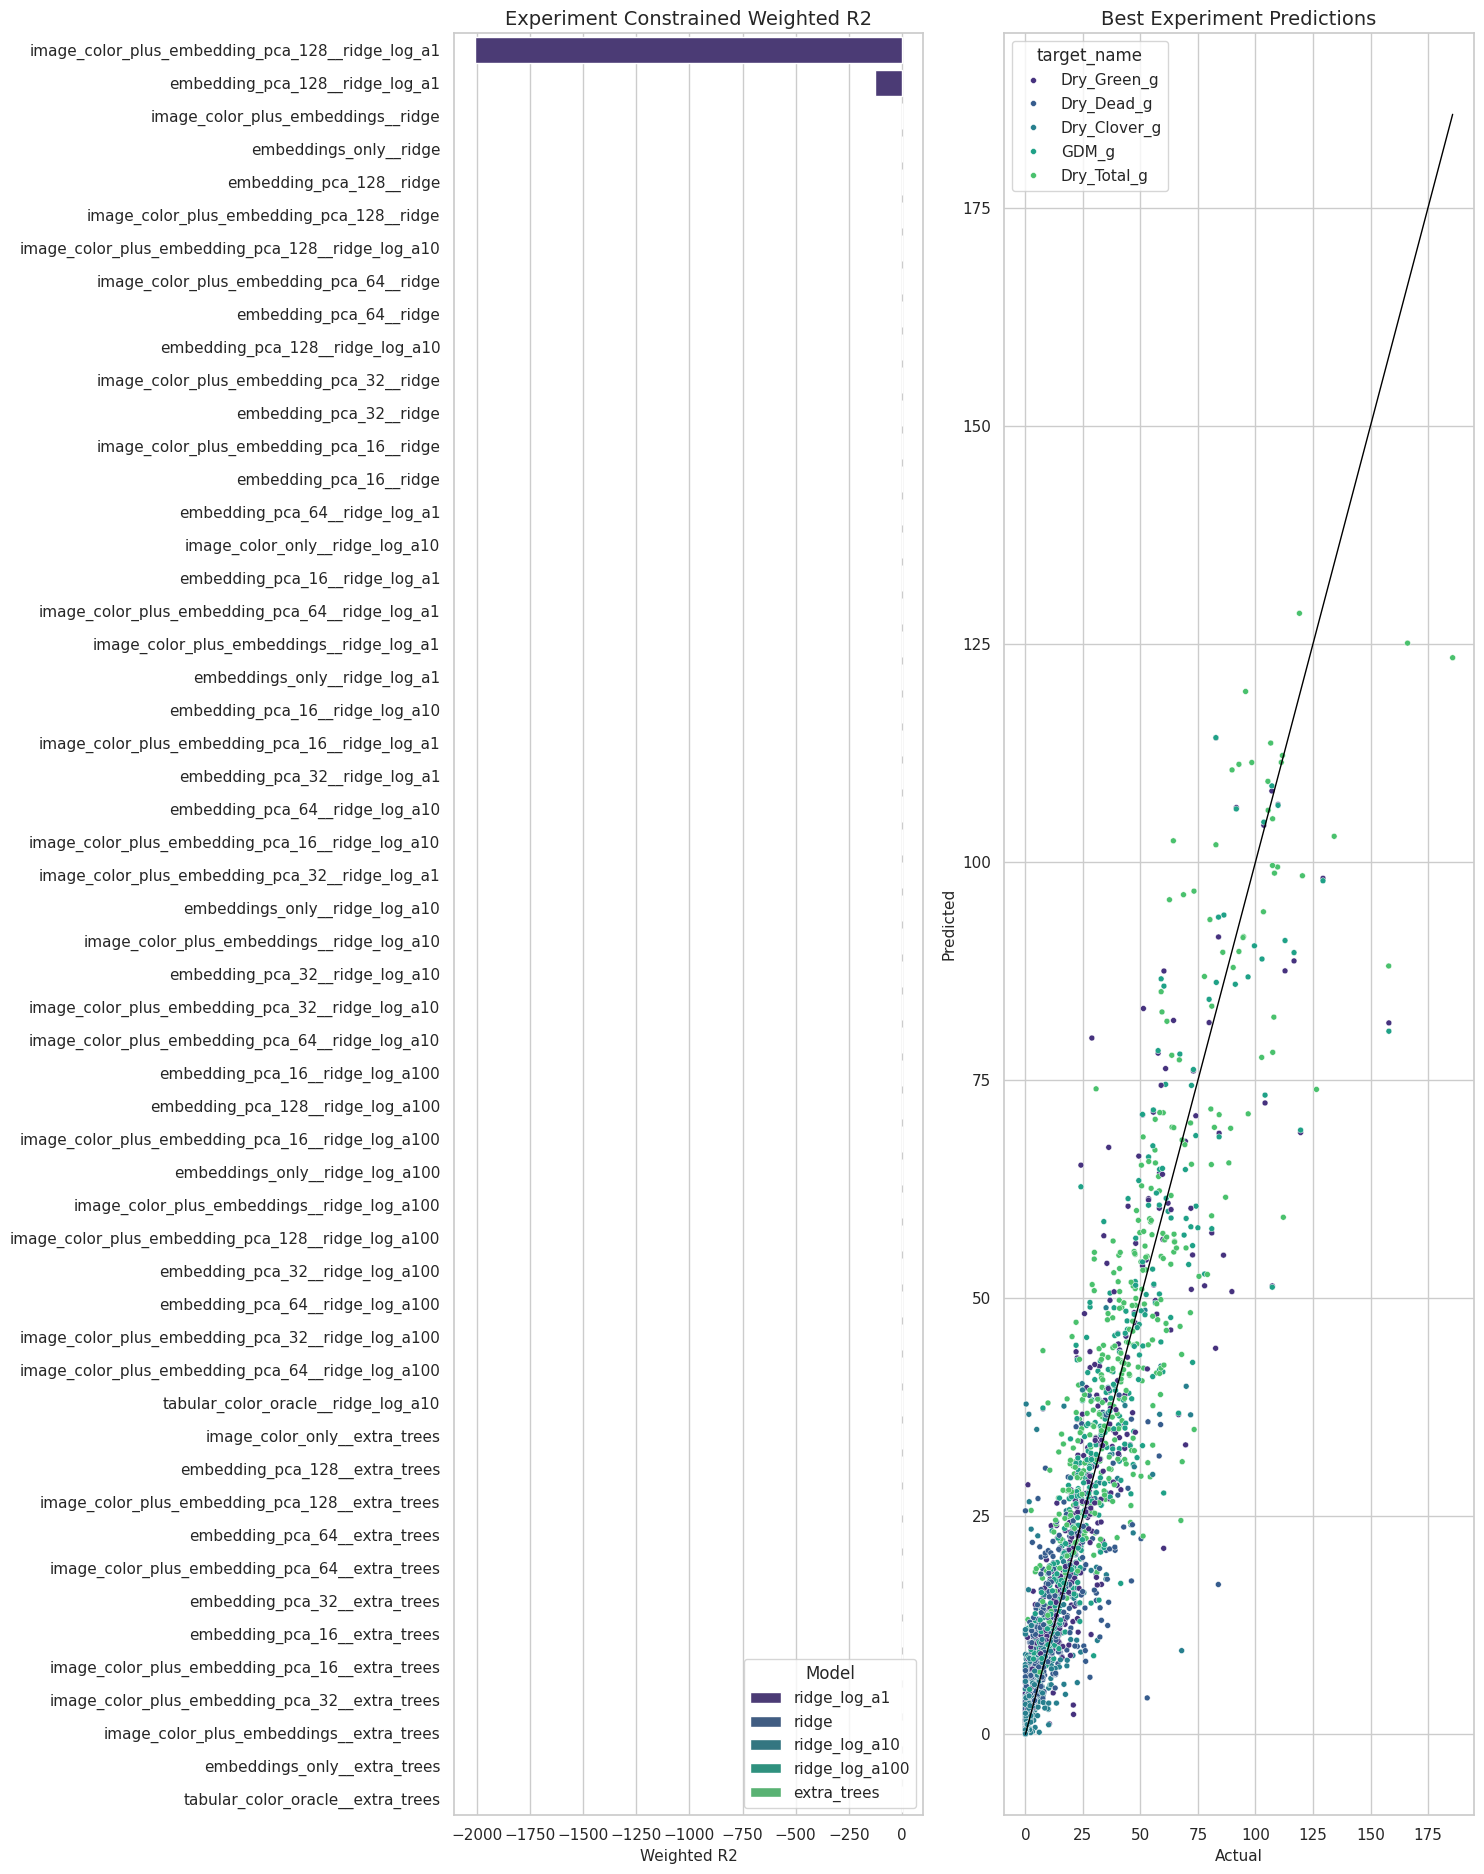

In [19]:
plot_summary = experiment_summary.sort_values('constrained_weighted_r2', ascending=True).copy()
fig_height = max(6, 0.35 * len(plot_summary))
fig, axes = plt.subplots(1, 2, figsize=(15, fig_height))
sns.barplot(data=plot_summary, y='experiment_label', x='constrained_weighted_r2', hue='model', dodge=False, ax=axes[0])
axes[0].set_title('Experiment Constrained Weighted R2')
axes[0].set_xlabel('Weighted R2')
axes[0].set_ylabel('')
axes[0].legend(title='Model', loc='lower right')

sns.scatterplot(data=best_oof, x='target', y='prediction', hue='target_name', s=18, ax=axes[1])
limit = max(best_oof['target'].max(), best_oof['prediction'].max())
axes[1].plot([0, limit], [0, limit], color='black', linewidth=1)
axes[1].set_title('Best Experiment Predictions')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
plt.tight_layout()
plt.show()


# 8. Export Artifacts

Bundle the experiment CSV outputs into one zip file for download from Kaggle. The zip is useful for deeper review, sharing, or keeping the notebook outputs lightweight.


In [20]:
from zipfile import ZipFile, ZIP_DEFLATED

artifact_files = [
    OUTPUT_DIR / 'embedding_experiment_summary.csv',
    OUTPUT_DIR / 'embedding_experiment_oof.csv',
    OUTPUT_DIR / 'embedding_experiment_per_target.csv',
    OUTPUT_DIR / 'embedding_experiment_segment_error.csv',
    OUTPUT_DIR / 'train_image_features.csv',
    OUTPUT_DIR / 'test_image_features.csv',
    OUTPUT_DIR / 'train_effnet_b0_embeddings.csv',
    OUTPUT_DIR / 'test_effnet_b0_embeddings.csv',
]

zip_path = OUTPUT_DIR / 'embedding_experiment_artifacts.zip'
with ZipFile(zip_path, 'w', compression=ZIP_DEFLATED) as zf:
    for path in artifact_files:
        if path.exists():
            zf.write(path, arcname=path.name)
            print(f'Added {path.name}')
        else:
            print(f'Skipped missing file: {path.name}')

print(f'Wrote {zip_path}')


Added embedding_experiment_summary.csv
Added embedding_experiment_oof.csv
Added embedding_experiment_per_target.csv
Added embedding_experiment_segment_error.csv
Added train_image_features.csv
Added test_image_features.csv
Added train_effnet_b0_embeddings.csv
Added test_effnet_b0_embeddings.csv
Wrote /kaggle/working/embedding_experiment_artifacts.zip


# 9. Key Findings Template

Use this section after running the notebook on Kaggle. Keep the baseline notebook as the stable benchmark and promote only experiments that beat it under grouped CV and improve the hard segments.

- Best experiment: fill from `experiment_summary`.
- Compare against current stable baseline selected constrained weighted R2: `0.81160`.
- Promote an embedding approach only if it improves grouped CV and does not worsen `Dry_Total_g / NSW`, `GDM_g / NSW`, or `Dry_Green_g / NSW`.
- Ridge and log-target Ridge are included because dense pretrained embeddings often work better with regularized linear models than with tree models.
- Ridge log alpha values `1`, `10`, and `100` are tested to avoid judging embeddings from a single regularization strength.
- PCA sizes `16`, `32`, `64`, and `128` are tested to check whether compressed embeddings help classical models.
- For the current notebook, use TorchVision EfficientNet-B0 ImageNet weights with internet enabled; no Kaggle model input is required.
- If an internet-on run improves CV, make it reproducible by attaching compatible PyTorch `.pth` weights and setting `ALLOW_MODEL_DOWNLOAD = False`.
